In [1]:
import pandas as pd

In [2]:
all_exp_1 = pd.read_csv('export_12-22_srt.csv')

In [3]:
# all_exp_1

In [4]:
all_exp_1.loc[all_exp_1['code_tov']=='.','code_tov']=0
all_exp_1['code_tov']=pd.to_numeric(all_exp_1['code_tov'])

In [5]:
all_exp_1 = all_exp_1.groupby(['year', 'co_dest']).sum()

In [6]:
all_exp_1= all_exp_1.reset_index()

In [7]:
all_exp_1

,year,co_dest,Unnamed: 0,code_tov,code_tra,ves_br
0,2012/01,ABH,1121297,1174539.0,5980.0,1.083520e+07
1,2012/01,AFG,208832,212474.0,1020.0,3.576946e+07
2,2012/01,AGO,83484,82565.0,260.0,7.506870e+05
3,2012/01,AIA,7244,7601.0,10.0,5.020400e+04
4,2012/01,ALB,2676,4103.0,20.0,6.084572e+06
...,...,...,...,...,...,...
18901,2022/12,VNM,372051666,1129992.0,4940.0,2.319669e+08
18902,2022/12,YEM,9130914,8331.0,90.0,4.800245e+05
18903,2022/12,ZAF,56889453,208910.0,850.0,1.358513e+07
18904,2022/12,ZMB,3663937,9818.0,80.0,3.812500e+04


In [8]:
import numpy as np

In [9]:
import sys
np.set_printoptions(threshold=sys.maxsize)

In [10]:
all_exp_1['year'] = all_exp_1['year'].apply(str).str.replace('.','/')

In [11]:
all_exp_1['year'].unique()

array(['2012/01', '2012/02', '2012/03', '2012/04', '2012/05', '2012/06',
       '2012/07', '2012/08', '2012/09', '2012/1', '2012/11', '2012/12',
       '2013/01', '2013/02', '2013/03', '2013/04', '2013/05', '2013/06',
       '2013/07', '2013/08', '2013/09', '2013/1', '2013/11', '2013/12',
       '2014/01', '2014/02', '2014/03', '2014/04', '2014/05', '2014/06',
       '2014/07', '2014/08', '2014/09', '2014/1', '2014/11', '2014/12',
       '2015/01', '2015/02', '2015/03', '2015/04', '2015/05', '2015/06',
       '2015/07', '2015/08', '2015/09', '2015/1', '2015/11', '2015/12',
       '2016/01', '2016/02', '2016/03', '2016/04', '2016/05', '2016/06',
       '2016/07', '2016/08', '2016/09', '2016/1', '2016/11', '2016/12',
       '2017/01', '2018/01', '2018/02', '2018/03', '2018/04', '2018/05',
       '2018/06', '2018/07', '2018/08', '2018/09', '2018/1', '2018/11',
       '2018/12', '2019/01', '2019/02', '2019/03', '2019/04', '2019/05',
       '2019/06', '2019/07', '2019/08', '2019/09', '2019/

In [12]:
# all_exp_1

In [13]:
for i in range(12,23):
    all_exp_1.loc[all_exp_1['year']=='20'+str(i)+'/1','year']='20'+str(i)+'/10'


In [14]:
# pd.to_datetime(all_exp_1['year'])

In [15]:
all_exp_1 = all_exp_1.groupby(['year','co_dest']).sum()

# .plot('Unnamed: 0')

In [16]:
all_exp_1

Unnamed: 0   code_tov  code_tra        ves_br
year    co_dest                                               
2012/01 ABH         1121297  1174539.0    5980.0  1.083520e+07
        AFG          208832   212474.0    1020.0  3.576946e+07
        AGO           83484    82565.0     260.0  7.506870e+05
        AIA            7244     7601.0      10.0  5.020400e+04
        ALB            2676     4103.0      20.0  6.084572e+06
...                     ...        ...       ...           ...
2022/12 VNM       372051666  1129992.0    4940.0  2.319669e+08
        YEM         9130914     8331.0      90.0  4.800245e+05
        ZAF        56889453   208910.0     850.0  1.358513e+07
        ZMB         3663937     9818.0      80.0  3.812500e+04
        ZWE         1838220     8517.0      40.0  2.300000e+01

[18906 rows x 4 columns]

In [17]:
all_exp_1 = all_exp_1.drop(['code_tov', 'code_tra', 'ves_br'], axis=1)

In [18]:
all_exp_1 = all_exp_1.unstack()

In [19]:
all_exp_1.isna().sum(axis=0)

            co_dest                            
Unnamed: 0  .                                      109
            AB                                     109
            ABH                                     12
            ABW                                    112
            AFG                                     13
                                                  ... 
            ЛИВИЯ                                  106
            ПАЛЕСТИНА,ГОСУДАРСТВО                   99
            ПАПСКИЙ ПРЕСТОЛ(ГОС.-ГОРОД ВАТИКАН)    120
            ПАПУА НОВАЯ ГВИНЕЯ                     105
            ЮЖНЫЙ СУДАН                            107
Length: 252, dtype: int64

In [20]:
sum(all_exp_1.isna().sum(axis=0)>100)

57

In [ ]:
all_exp_1.index = pd.DatetimeIndex(all_exp_1.index)

In [28]:
tot_df = all_exp_1.groupby(all_exp_1.index.year).sum().sum(axis=1)

In [29]:
all_exp_1 = all_exp_1.loc['2018':,~(all_exp_1.isna().sum(axis=0)>100)]

In [30]:
all_exp_1.isna().sum(axis=0)

            co_dest                           
Unnamed: 0  ABH                                   12
            AFG                                   13
            AGO                                   12
            ALB                                    6
            AND                                   39
                                                  ..
            ZAF                                    3
            ZMB                                   28
            ZWE                                   31
            ЛАОССКАЯ НАРОДНО-ДЕМОК. РЕСПУБЛИКА    60
            ПАЛЕСТИНА,ГОСУДАРСТВО                 60
Length: 195, dtype: int64

In [31]:
perc_df = all_exp_1.div(all_exp_1.sum(axis=1), axis=0)

In [32]:
all_exp_short = all_exp_1.loc[:,perc_df.mean(axis=0)>0.025]

In [33]:
all_exp_short

Unnamed: 0                                            \
co_dest             ABH           AZE           CHN           DEU   
year                                                                
2018-01-01  342424430.0  6.052885e+08  3.837048e+08  3.279714e+08   
2018-02-01  453651804.0  7.279094e+08  2.907356e+08  3.039362e+08   
2018-03-01  456708112.0  7.841317e+08  3.730772e+08  2.401029e+08   
2018-04-01  758957148.0  7.491193e+08  3.817532e+08  2.505429e+08   
2018-05-01  460935978.0  7.821413e+08  3.489390e+08  2.469342e+08   
2018-06-01  474050583.0  7.578858e+08  3.885056e+08  2.541979e+08   
2018-07-01  607781826.0  7.990745e+08  3.997507e+08  2.591953e+08   
2018-08-01  763805498.0  8.227022e+08  3.815018e+08  2.972564e+08   
2018-09-01  557211857.0  8.221170e+08  3.295740e+08  3.026459e+08   
2018-10-01  516893754.0  8.883558e+08  3.434101e+08  3.591022e+08   
2018-11-01  487497475.0  8.580097e+08  3.342185e+08  3.205796e+08   
2018-12-01  564432889.0  9.425096e+08  3.541909e+08  2.674864e+08   
2019-01-01  335440926.0  6.862284e+08  3.326376e+08  2.330366e+08   
2019-02-01  455567895.0  8.020052e+08  2.657504e+08  3.489727e+08   
2019-03-01  477738591.0  8.404939e+08  4.580207e+08  3.434681e+08   
2019-04-01  555370782.0  7.933070e+08  4.121357e+08  4.421006e+08   
2019-05-01  512563326.0  8.056463e+08  3.986777e+08  2.660891e+08   
2019-06-01  571663552.0  8.959390e+08  4.220147e+08  3.580911e+08   
2019-07-01  549197599.0  8.586469e+08  5.049808e+08  2.369063e+08   
2019-08-01  634639931.0  8.318475e+08  4.370613e+08  2.110747e+08   
2019-09-01  627020123.0  8.855735e+08  3.984018e+08  2.906492e+08   
2019-10-01  619655938.0  1.150724e+09  6.231483e+08  7.746452e+08   
2019-11-01  649713928.0  1.177393e+09  6.454320e+08  7.956932e+08   
2019-12-01  663083453.0  1.262138e+09  6.668586e+08  7.923994e+08   
2020-01-01          NaN  8.605300e+08  3.527747e+08  6.593558e+08   
2020-02-01          NaN  1.038332e+09  3.358184e+08  7.083219e+08   
2020-03-01          NaN  1.086545e+09  3.134292e+08  6.976251e+08   
2020-04-01          NaN  8.393396e+08  3.351826e+08  6.940118e+08   
2020-05-01          NaN  9.484740e+08  3.184100e+08  7.224946e+08   
2020-06-01          NaN  1.028016e+09  4.162970e+08  7.765886e+08   
2020-07-01          NaN  9.778905e+08  3.725618e+08  7.719280e+08   
2020-08-01          NaN  1.037070e+09  3.968844e+08  7.785675e+08   
2020-09-01          NaN  1.054515e+09  4.953587e+08  8.336626e+08   
2020-10-01          NaN  1.042304e+09  5.155186e+08  8.840681e+08   
2020-11-01          NaN  1.092466e+09  4.278140e+08  8.472429e+08   
2020-12-01          NaN  1.095008e+09  4.898749e+08  8.798225e+08   
2021-01-01  435378190.0  4.970023e+08  6.659280e+08  4.928196e+08   
2021-02-01  554667145.0  6.078714e+08  6.240523e+08  6.779165e+08   
2021-03-01  658467947.0  6.764985e+08  6.822685e+08  6.109622e+08   
2021-04-01  649903596.0  7.133944e+08  7.901248e+08  6.382530e+08   
2021-05-01  645633017.0  6.655805e+08  7.733809e+08  5.756316e+08   
2021-06-01  685777954.0  7.197177e+08  7.606207e+08  6.305177e+08   
2021-07-01  711183060.0  6.039925e+08  7.266081e+08  6.027580e+08   
2021-08-01  575204425.0  6.693661e+08  7.978645e+08  5.500798e+08   
2021-09-01  651745321.0  6.599608e+08  7.402620e+08  6.660672e+08   
2021-10-01  721829231.0  5.922933e+08  7.743750e+08  7.208383e+08   
2021-11-01  638449034.0  6.237869e+08  7.624601e+08  6.710351e+08   
2021-12-01  741031514.0  8.032796e+08  7.913932e+08  6.796175e+08   
2022-01-01  645871633.0  1.174354e+09  9.625958e+08  1.546550e+09   
2022-02-01  778783699.0  1.285019e+09  9.744956e+08  1.846609e+09   
2022-03-01  838186368.0  1.277592e+09  7.376699e+08  1.371329e+09   
2022-04-01  853645995.0  1.333550e+09  8.173460e+08  1.061004e+09   
2022-05-01  913576818.0  1.186690e+09  8.612989e+08  9.653793e+08   
2022-06-01  977410028.0  1.190423e+09  1.045047e+09  9.948839e+08   
2022-07-01  970011377.0  1.200805e+09  9.977753e+08  8.908545e+08   
2022-08-01 

In [34]:
all_exp_short.columns = all_exp_short.columns.get_level_values(level=1) 


In [35]:
import matplotlib.pyplot as plt

In [36]:
all_exp_short.index[::2]

DatetimeIndex(['2018-01-01', '2018-03-01', '2018-05-01', '2018-07-01',
               '2018-09-01', '2018-11-01', '2019-01-01', '2019-03-01',
               '2019-05-01', '2019-07-01', '2019-09-01', '2019-11-01',
               '2020-01-01', '2020-03-01', '2020-05-01', '2020-07-01',
               '2020-09-01', '2020-11-01', '2021-01-01', '2021-03-01',
               '2021-05-01', '2021-07-01', '2021-09-01', '2021-11-01',
               '2022-01-01', '2022-03-01', '2022-05-01', '2022-07-01',
               '2022-09-01', '2022-11-01'],
              dtype='datetime64[ns]', name='year', freq=None)

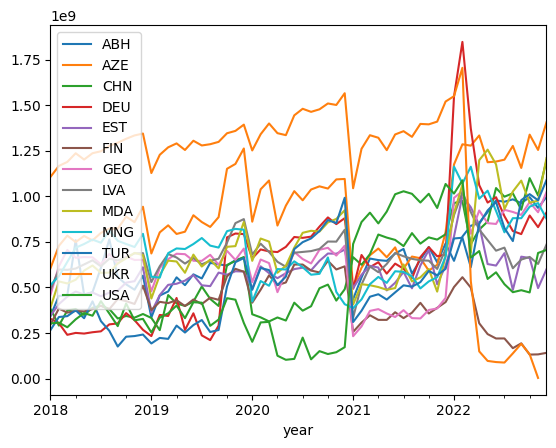

In [39]:
all_exp_short.plot()
plt.legend(loc='upper left')
# plt.xticks(np.arange(0, 5*12, step=12), all_exp_short.index[::12]);

In [40]:
all_exp_short.index = pd.DatetimeIndex(all_exp_short.index)


In [41]:
year_df = all_exp_short.groupby(all_exp_short.index.year).sum()

In [42]:
# year_df
year_df.index

Index([2018, 2019, 2020, 2021, 2022], dtype='int32', name='year')

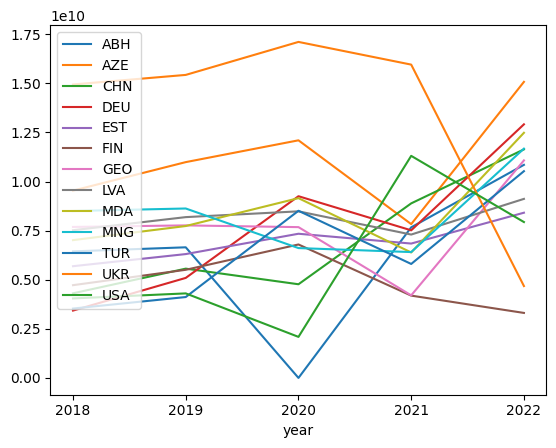

In [43]:
year_df.plot()
plt.legend(loc='upper left')
plt.xticks(year_df.index, year_df.index);

In [44]:
year_df = year_df.loc[2021:,:].T

In [45]:
year_df['diff'] = year_df.iloc[:,1]-year_df.iloc[:,0]

In [46]:
year_df = year_df.sort_values(by='diff')

In [47]:
year_df = year_df.drop(['diff'], axis=1)

In [48]:
year_df

year,2021,2022
co_dest,,
UKR,1.595587e+10,4.678796e+09
USA,1.130888e+10,7.938181e+09
FIN,4.191317e+09,3.310087e+09
EST,6.842896e+09,8.413489e+09
LVA,7.301260e+09,9.117407e+09
CHN,8.889338e+09,1.163872e+10
ABH,7.669270e+09,1.085123e+10
TUR,5.803823e+09,1.052888e+10
MNG,6.409274e+09,1.167611e+10


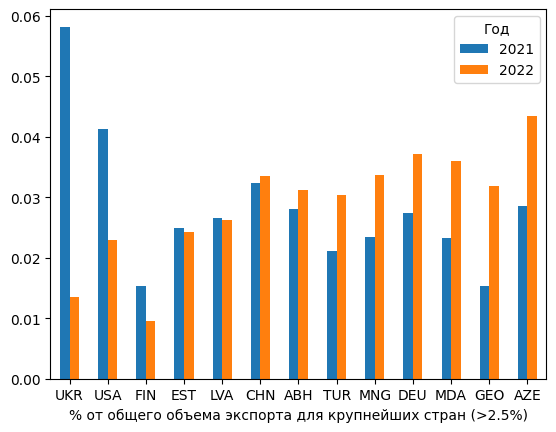

In [54]:
year_df.div(tot_df.loc['2021':]).plot.bar()
plt.xticks(rotation=0);
plt.xlabel('% от общего объема экспорта для крупнейших стран (>2.5%)')
plt.legend(title="Год")

year
2021    2.739716e+11
2022    3.470531e+11
dtype: float64